In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import jensenshannon
import numpy as np
device = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Parameters
# ============================================================

mu_x0 = 3.0
var_x0 = 0.4
sigma_base = 1
eps_base=3
var_z0 = var_x0 + sigma_base**2  # 4.4


n_samples = 30000
eps_mean = 3.0/sigma_base

mu_z0 = mu_x0 + sigma_base * eps_mean
var_z0 = var_x0 + sigma_base**2



def sample_x0(batch_size, mu_x=3.0, var_x=0.4):
    std_x = torch.sqrt(torch.tensor(var_x, device=device))
    x0 = mu_x + std_x * torch.randn(batch_size, 1, device=device)
    return x0


def sample_z0_from_x0(x0):
    """
    Observation model:
    
        Z_0 = X_0 + sigma * eps_0, with eps_0 ~ N(eps_mean, 1)
    """
    eps0 = eps_mean + torch.randn_like(x0)
    z0 = x0 + sigma_base * eps0
    return z0


def sample_joint_data(batch_size):
    """
    Return both hidden X_0 and observed Z_0.
    """
    x0 = sample_x0(batch_size, mu_x=3.0, var_x=0.4)
    z0 = sample_z0_from_x0(x0)
    return x0, z0


def sample_data(batch_size):
    """
    The DDPM only observes Z_0.
    """
    _, z0 = sample_joint_data(batch_size)
    return z0

# Choix simple pour tester avec sigma_t^2 = sigma^2 / 2^t
T = 200
beta_start = 1e-4
beta_end = 0.07
betas = torch.linspace(beta_start, beta_end, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))


def sigma2_t(t, x_shape):
    """
    sigma_t^2 = sigma_base^2 / 2^t
    """
    out = sigma_base**2 / (2.0 ** t.float())
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

def extract_sigma2(t, x_shape):
    """
    Return sigma_t^2 reshaped for broadcasting.
    """
    out = sigma2_t(t, x_shape)
    return out.reshape(-1, *([1] * (len(x_shape) - 1)))
def extract_alpha_bar_prev(t, x_shape):
    """
    Return alpha_bar_{t-1}.
    For t=0, alpha_bar_{-1} is interpreted as 1,
    because X_{t-1}=X_0 at the final step.
    """
    out = torch.ones_like(t, dtype=torch.float, device=t.device)

    mask = t > 0
    if mask.any():
        out[mask] = alpha_bars.gather(0, t[mask] - 1)

    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

Dans ce notebook, on regarde ce qu'il se passe quand on est dans un cas où on a une forme explicite du score et on teste notre sampler dans ce cas : on se place dans le cas où les données sot distribuées selon une Gaussienne. La corruption consiste à leur ajouter un bruit gaussien avec une moyenne non nulle.

Comme on est dans un cas où tout est Gaussien, on peut calculer le score (et la dérivée du score pour la covariance de Tweedie) 


Dans le cas où $Z=\alpha X + \sigma \epsilon$, on a 
$$
\mathbb{E}[X \mid Z = z]
=
\frac{1}{\alpha}
\left(
z + \sigma^2 \nabla_z \log p_Z(z)
\right)
$$

et 

$$
\operatorname{Cov}(X \mid Z = z)
=
\frac{\sigma^2}{\alpha^2} I
+
\frac{\sigma^4}{\alpha^2}
\nabla_z^2 \log p_Z(z)
$$

Comme $Z_t$ est défini par le forward classique de DDPM et qu'on connait la loi de Z_0 via celle de X_0, on a une formule expicite pour le score 
$$\nabla_{z_t}\log f_t^Z(z_t)
=
-
\frac{
z_t
-
\sqrt{\overline{\alpha}_t}
\left(
\mu_{x_0}
+
\sigma_{\mathrm{base}}\mu_\epsilon
\right)
}{
\overline{\alpha}_t
\left(
\operatorname{var}_{x_0}
+
\sigma_{\mathrm{base}}^2
\right)
+
1-\overline{\alpha}_t
}.
$$

car le score d'une gaussienne $Y \sim \mathcal N(\mu, v)$ est donné par 
$$\nabla_y \log p_Y(y)=
=
-\frac{y-\mu}{v}.$$

De plus, 
$$Z_t
\sim
\mathcal N
\left(
\sqrt{\overline{\alpha}_t}
\left(
\mu_{x_0}+\sigma_{\mathrm{base}}\mu_\epsilon
\right),
\overline{\alpha}_t
\left(
\operatorname{var}_{x_0}+\sigma_{\mathrm{base}}^2
\right)
+
1-\overline{\alpha}_t
\right).$$

Pour la covariance de Tweedie, si on écrit 

$$
v_t
=
\beta_t+\alpha_t\sigma_{t-1}^2.$$
alors 
$$\operatorname{Cov}(X_{t-1}\mid Z_t=z)
=
\frac{1}{\alpha_t}
\left[
v_t I
+
v_t^2
\nabla_z^2 \log p_t^Z(z)
\right]$$
et 
$$\operatorname{Cov}(X_{t-1}\mid Z_t=z)
=
\frac{1}{\alpha_t}
\left[
\left(
\beta_t+\alpha_t\frac{\sigma^2}{2^{t-1}}
\right)I
+
\left(
\beta_t+\alpha_t\frac{\sigma^2}{2^{t-1}}
\right)^2
\nabla_z^2\log p_t^Z(z)
\right].$$

et dans le cas Gaussien 

In [3]:
@torch.no_grad()
def true_score_z_gaussian(zt, t):
    """
    True score of Z_t for:
        X_0 ~ N(mu_x0, var_x0)
        Z_0 = X_0 + sigma_base * epsilon_0
        epsilon_0 ~ N(eps_mean, I)

    Hence:
        Z_0 ~ N(mu_x0 + sigma_base * eps_mean,
                var_x0 + sigma_base^2).
    """

    alpha_bar_t = extract(alpha_bars, t, zt.shape)

    mu_z0 = mu_x0 + sigma_base * eps_mean
    var_z0 = var_x0 + sigma_base**2

    mu_z_t = torch.sqrt(alpha_bar_t) * mu_z0
    var_z_t = alpha_bar_t * var_z0 + (1.0 - alpha_bar_t)

    score = -(zt - mu_z_t) / var_z_t
    return score


In [4]:
@torch.no_grad()
def p_sample_hidden_x_true_score(zt, t):
    """
    Sample adapted but we use the actual Gaussian score of Z_t, which is known in this synthetic example.
    """

    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)
    alpha_bar_t = extract(alpha_bars, t, zt.shape)
    # sigma_{t-1}^2
    sigma_prev2 = extract_sigma2(t, zt.shape)
    sigma_prev = torch.sqrt(sigma_prev2)
    # delta_t = beta_t + alpha_t * sigma_{t-1}^2
    delta_t = beta_t + alpha_t * sigma_prev2
    
    # Bias induced by E[epsilon_{t-1}] = eps_mean.
    # Z_t | X_{t-1}=x is N(sqrt(alpha_t)*(x + sigma_{t-1} eps_mean), delta_t I).
    bias_t = torch.sqrt(alpha_t) * sigma_prev * eps_mean

    # True score of f_t^Z
    score = true_score_z_gaussian(zt, t)
    
    var_z0 = var_x0 + sigma_base**2
    var_z_t = alpha_bar_t * var_z0 + (1.0 - alpha_bar_t)
    hessian = -1.0 / var_z_t
    var_x_prev = (delta_t + (delta_t**2) * hessian) / alpha_t
    noise_x = torch.randn_like(zt)
    
    # 
    # Tweedie estimate: mean of X_{t-1} | Z_t
    x_prev_hat = (zt -bias_t + delta_t * score) / torch.sqrt(alpha_t)

    #Tweedie variance: var(X_{t-1} | Z_t) = delta_t / alpha_t

    x_prev = x_prev_hat + torch.sqrt(var_x_prev) * noise_x



    noise_z = torch.randn_like(zt)
    z_prev = x_prev + sigma_prev * eps_mean + torch.sqrt(sigma_prev2) * noise_z

    return z_prev, x_prev, x_prev_hat

In [5]:
@torch.no_grad()
def sample_hidden_x_from_z_ddpm( n_samples):
    """
    Full adapted reverse chain.

    Returns:
        x0_hat    : generated latent X_0
        z0_hat    : generated observed Z_0
        trajectory: selected intermediate states
    """
  
    zt = torch.randn(n_samples, 1, device=device)

    trajectory = []
    x_prev_hat = None

    for time_step in reversed(range(T)):
        t = torch.full((n_samples,), time_step, device=device, dtype=torch.long)

        z_prev, x_prev, x_prev_hat= p_sample_hidden_x_true_score( zt, t)

        if time_step in [T - 1, 200, 100, 50, 10, 0]:
            trajectory.append(
                {
                    "time": time_step,
                    "z_t": zt.detach().cpu(),
                    "x_prev": x_prev.detach().cpu(),
                    "x_prev_hat": x_prev_hat.detach().cpu(),
                    "z_prev": z_prev.detach().cpu(),
                }
            )

        zt = z_prev

    z0_hat = zt.detach().cpu()
    x0_hat = x_prev.detach().cpu()

    return x0_hat, z0_hat, trajectory

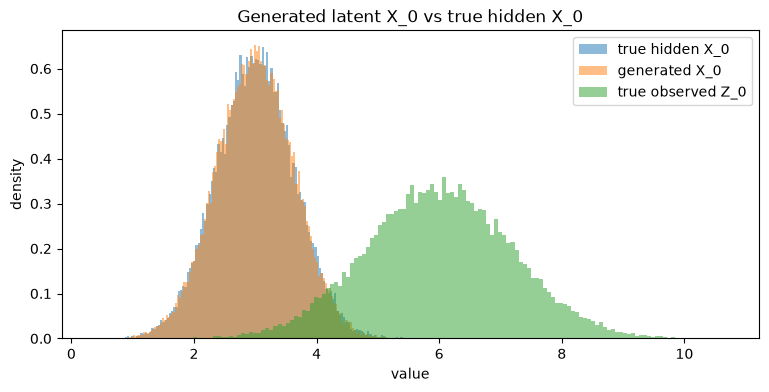

In [6]:
x0_gen, z0_gen, trajectory = sample_hidden_x_from_z_ddpm( n_samples=30000)

x0_real, z0_real = sample_joint_data(30000)
x0_real = x0_real.detach().cpu()
z0_real = z0_real.detach().cpu()

plt.figure(figsize=(9, 4))
plt.hist(x0_real.numpy(), bins=150, density=True, alpha=0.5, label="true hidden X_0")
plt.hist(x0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated X_0")
plt.hist(z0_real.numpy(), bins=150, density=True, alpha=0.5, label="true observed Z_0")
plt.title("Generated latent X_0 vs true hidden X_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

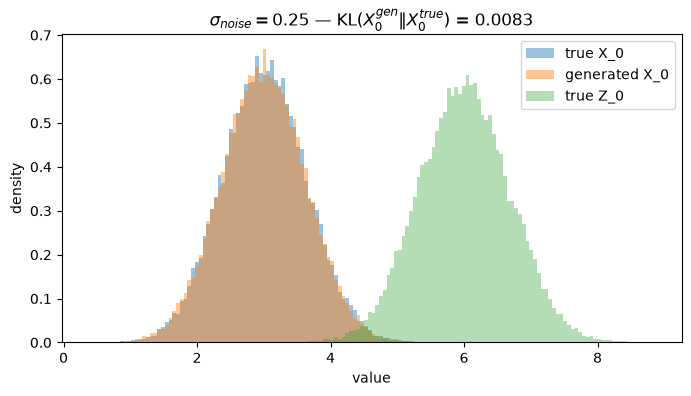

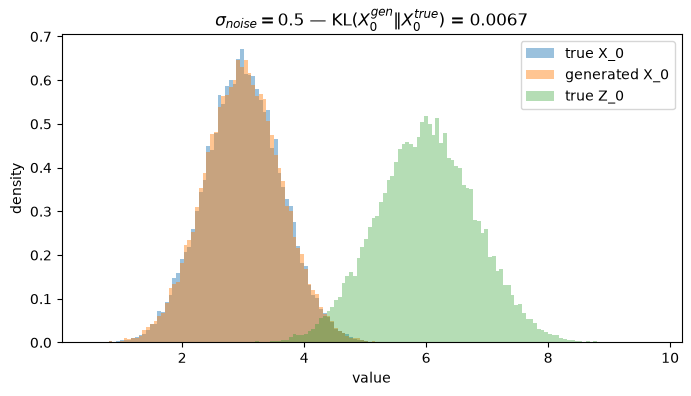

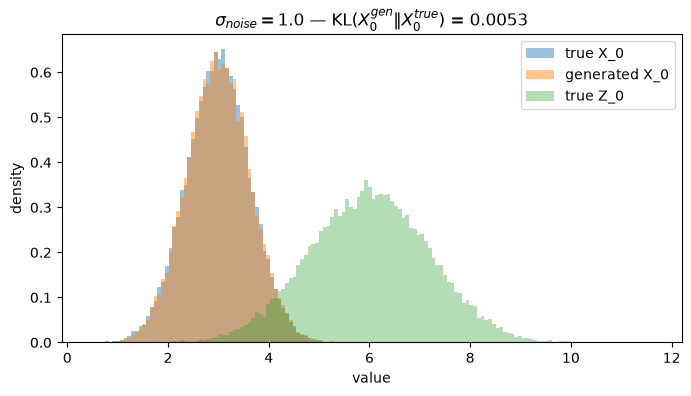

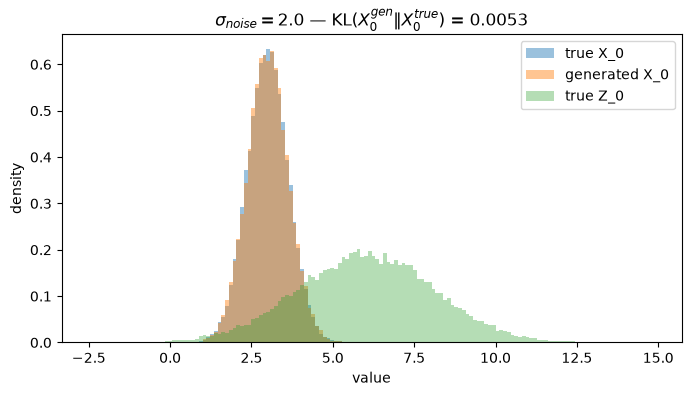

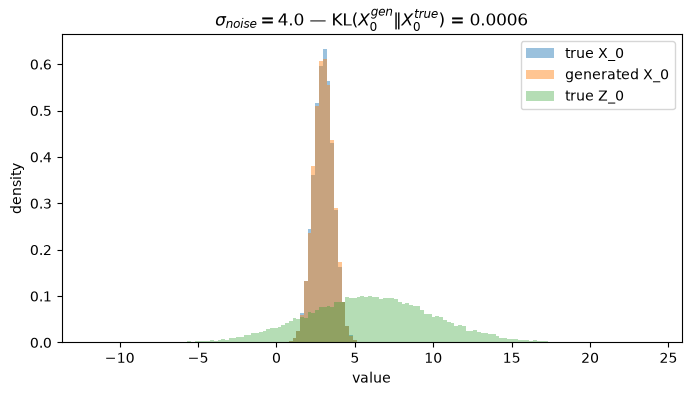

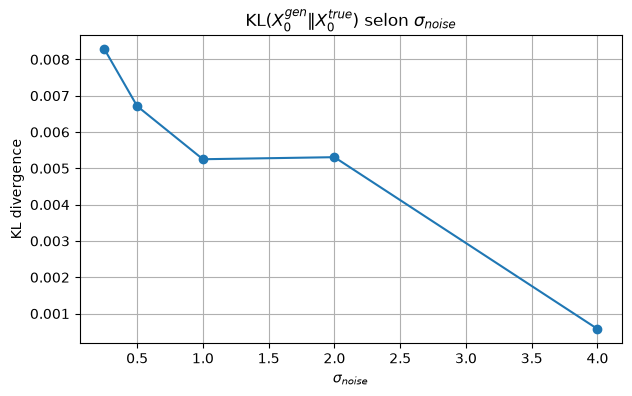

In [7]:
sigma_noise_values = [0.25, 0.5, 1.0, 2.0, 4.0]
n_eval = 30000
bins = 150
eps = 1e-12

kl_divergences = []

old_sigma_base = sigma_base
old_eps_mean = eps_mean

def empirical_kl_from_samples(samples_p, samples_q, bins=150, value_range=None, eps=1e-12):
    """
    Calcule KL(P || Q) à partir de deux ensembles de samples.
    Ici P = distribution générée, Q = distribution vraie.
    """
    p_counts, bin_edges = np.histogram(samples_p, bins=bins, range=value_range, density=False)
    q_counts, _ = np.histogram(samples_q, bins=bin_edges, density=False)

    p = p_counts.astype(float) + eps
    q = q_counts.astype(float) + eps

    p = p / p.sum()
    q = q / q.sum()

    return np.sum(p * np.log(p / q))


for sigma_noise in sigma_noise_values:
    sigma_base = sigma_noise
    eps_mean = 3.0/sigma_base
    out = sample_hidden_x_from_z_ddpm(n_samples=n_eval)
    x0_gen, z0_gen = out[0], out[1]

    x0_real, z0_real = sample_joint_data(n_eval)

    x0_real = x0_real.detach().cpu().numpy().reshape(-1)
    z0_real = z0_real.detach().cpu().numpy().reshape(-1)
    x0_gen = x0_gen.detach().cpu().numpy().reshape(-1)
    z0_gen = z0_gen.detach().cpu().numpy().reshape(-1)

    value_range = (
        min(x0_real.min(), x0_gen.min(), z0_real.min(), z0_gen.min()),
        max(x0_real.max(), x0_gen.max(), z0_real.max(), z0_gen.max())
    )

    kl = empirical_kl_from_samples(
        samples_p=x0_gen,
        samples_q=x0_real,
        bins=bins,
        value_range=value_range,
        eps=eps
    )

    kl_divergences.append(kl)

    plt.figure(figsize=(8, 4))

    plt.hist(x0_real, bins=bins, range=value_range, density=True, alpha=0.45, label="true X_0")
    plt.hist(x0_gen, bins=bins, range=value_range, density=True, alpha=0.45, label="generated X_0")
    plt.hist(z0_real, bins=bins, range=value_range, density=True, alpha=0.35, label="true Z_0")

    plt.title(rf"$\sigma_{{noise}}={sigma_noise}$ — KL$(X_0^{{gen}} \Vert X_0^{{true}})$ = {kl:.4f}")
    plt.xlabel("value")
    plt.ylabel("density")
    plt.legend()
    plt.show()


plt.figure(figsize=(7, 4))
plt.plot(sigma_noise_values, kl_divergences, marker="o")
plt.title(r"KL$(X_0^{gen} \Vert X_0^{true})$ selon $\sigma_{noise}$")
plt.xlabel(r"$\sigma_{noise}$")
plt.ylabel("KL divergence")
plt.grid(True)
plt.show()

sigma_base = old_sigma_base
eps_mean = old_eps_mean

Comparaison avec Tweedie en 1 seule étape

In [8]:
@torch.no_grad()
def true_score_z0_gaussian(z0):
    """
    Score exact de Z_0.

    Z_0 = X_0 + sigma_base * eps_0
    eps_0 ~ N(eps_mean, 1)

    Donc :
        Z_0 ~ N(mu_x0 + sigma_base * eps_mean,
                var_x0 + sigma_base**2)
    """
    mu_z0 = mu_x0 + sigma_base * eps_mean
    var_z0 = var_x0 + sigma_base**2

    return -(z0 - mu_z0) / var_z0


@torch.no_grad()
def tweedie_one_step_x0_from_z0(z0, sample_posterior=True, return_mean=True):
    """
    Génère X_0 en un seul step à partir de Z_0 avec Tweedie.

    Si sample_posterior=True :
        X_0^{gen} ~ p(X_0 | Z_0)

    Si sample_posterior=False :
        X_0^{gen} = E[X_0 | Z_0]
    """
    sigma2 = sigma_base**2

    score_z0 = true_score_z0_gaussian(z0)

    # Moyenne de Tweedie avec correction du biais non centré
    x0_mean = z0 - sigma_base * eps_mean + sigma2 * score_z0

    # Covariance de Tweedie dans le cas gaussien
    post_var = var_x0 * sigma2 / (var_x0 + sigma2)
    post_std = torch.sqrt(
        torch.tensor(post_var, device=z0.device, dtype=z0.dtype)
    )

    if sample_posterior:
        x0_gen = x0_mean + post_std * torch.randn_like(z0)
    else:
        x0_gen = x0_mean

    if return_mean:
        return x0_gen, x0_mean, post_var

    return x0_gen


def gaussian_kl_1d(mu_p, var_p, mu_q, var_q):
    """
    KL(N(mu_p, var_p) || N(mu_q, var_q)).
    """
    return 0.5 * (
        np.log(var_q / var_p)
        + (var_p + (mu_p - mu_q)**2) / var_q
        - 1.0
    )

sigma=   0 | KL sampled=0.000000 | KL mean-only=0.000000 | KL mean-only exact=0.000000 | Var(X0|Z0)=0.000000


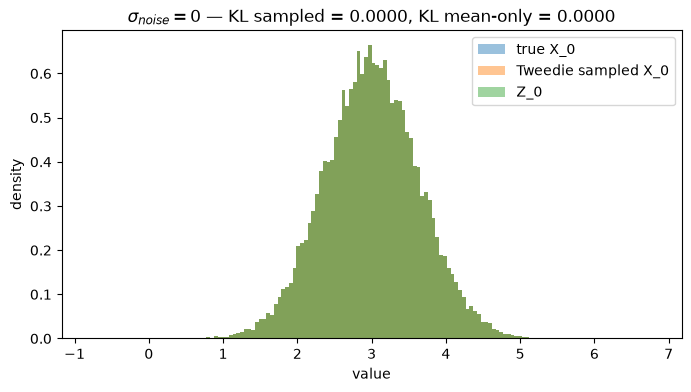

sigma=0.25 | KL sampled=0.007730 | KL mean-only=0.010170 | KL mean-only exact=0.005023 | Var(X0|Z0)=0.054054


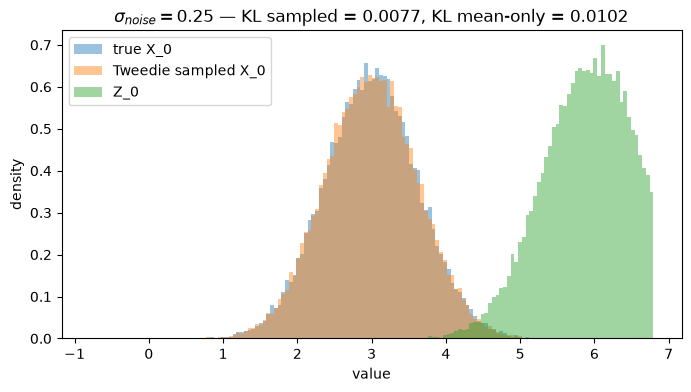

sigma= 0.5 | KL sampled=0.005599 | KL mean-only=0.053450 | KL mean-only exact=0.050446 | Var(X0|Z0)=0.153846


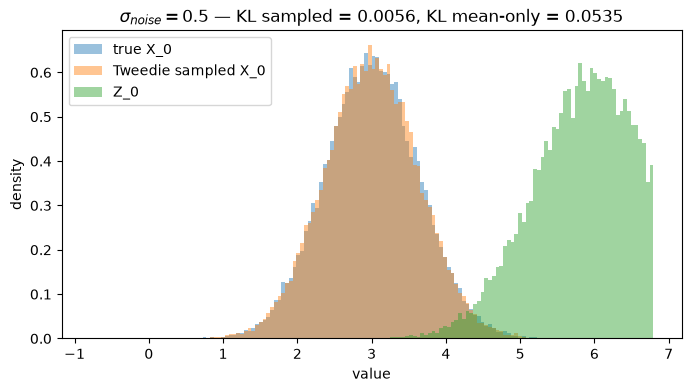

sigma= 1.0 | KL sampled=0.007707 | KL mean-only=0.270623 | KL mean-only exact=0.269239 | Var(X0|Z0)=0.285714


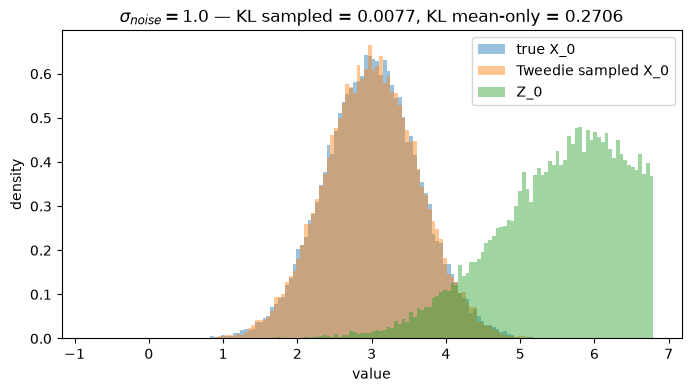

sigma= 2.0 | KL sampled=0.006767 | KL mean-only=0.738990 | KL mean-only exact=0.744402 | Var(X0|Z0)=0.363636


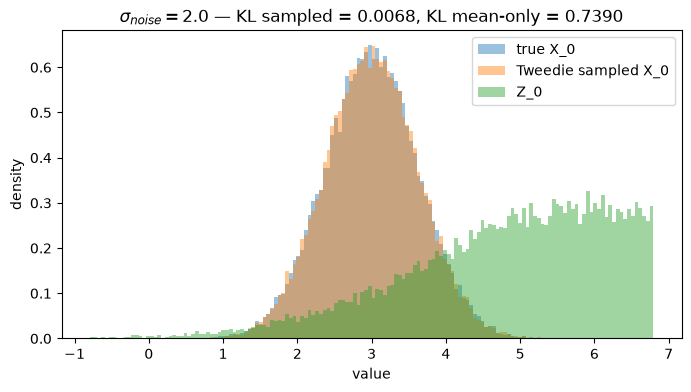

sigma= 4.0 | KL sampled=0.010376 | KL mean-only=1.357728 | KL mean-only exact=1.368981 | Var(X0|Z0)=0.390244


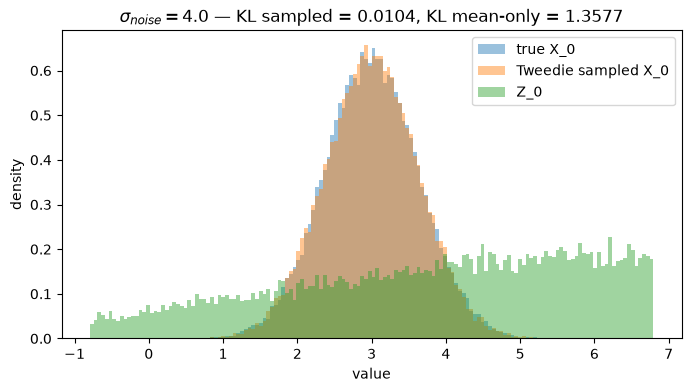

In [12]:
sigma_noise_values = [0, 0.25, 0.5, 1.0, 2.0, 4.0]
n_eval = 30000
bins = 150
eps = 1e-12

kl_tweedie_sampled = []
kl_tweedie_mean_only = []
kl_tweedie_mean_only_exact = []

old_sigma_base = sigma_base
old_eps_mean = eps_mean

value_range_x = (
    mu_x0 - 6.0 * np.sqrt(var_x0),
    mu_x0 + 6.0 * np.sqrt(var_x0)
)

for sigma_noise in sigma_noise_values:
    sigma_base = float(sigma_noise)
    if sigma_base != 0:
        eps_mean = 3.0 / sigma_base

    x0_real, z0_real = sample_joint_data(n_eval)

    x0_tweedie_sampled, x0_tweedie_mean, post_var = tweedie_one_step_x0_from_z0(
        z0_real,
        sample_posterior=True,
        return_mean=True
    )

    x0_real_np = x0_real.detach().cpu().numpy().reshape(-1)
    x0_sampled_np = x0_tweedie_sampled.detach().cpu().numpy().reshape(-1)
    x0_mean_np = x0_tweedie_mean.detach().cpu().numpy().reshape(-1)

    kl_sampled = empirical_kl_from_samples(
        samples_p=x0_sampled_np,
        samples_q=x0_real_np,
        bins=bins,
        value_range=value_range_x,
        eps=eps
    )

    kl_mean_only = empirical_kl_from_samples(
        samples_p=x0_mean_np,
        samples_q=x0_real_np,
        bins=bins,
        value_range=value_range_x,
        eps=eps
    )

    # Loi de la moyenne de Tweedie :
    # E[X0 | Z0] ~ N(mu_x0, var_x0^2 / (var_x0 + sigma^2))
    var_mean_only = var_x0**2 / (var_x0 + sigma_base**2)

    kl_mean_exact = gaussian_kl_1d(
        mu_p=mu_x0,
        var_p=var_mean_only,
        mu_q=mu_x0,
        var_q=var_x0
    )

    kl_tweedie_sampled.append(kl_sampled)
    kl_tweedie_mean_only.append(kl_mean_only)
    kl_tweedie_mean_only_exact.append(kl_mean_exact)

    print(
        f"sigma={sigma_noise:>4} | "
        f"KL sampled={kl_sampled:.6f} | "
        f"KL mean-only={kl_mean_only:.6f} | "
        f"KL mean-only exact={kl_mean_exact:.6f} | "
        f"Var(X0|Z0)={post_var:.6f}"
    )

    plt.figure(figsize=(8, 4))
    plt.hist(x0_real_np, bins=bins, range=value_range_x, density=True, alpha=0.45, label="true X_0")
    plt.hist(x0_sampled_np, bins=bins, range=value_range_x, density=True, alpha=0.45, label="Tweedie sampled X_0")
    plt.hist(z0_real, bins=bins, range=value_range_x, density=True, alpha=0.45, label="Z_0")
    plt.title(
        rf"$\sigma_{{noise}}={sigma_noise}$ — "
        rf"KL sampled = {kl_sampled:.4f}, KL mean-only = {kl_mean_only:.4f}"
    )
    plt.xlabel("value")
    plt.ylabel("density")
    plt.legend()
    plt.show()



sigma_base = old_sigma_base
eps_mean = old_eps_mean